Multimodal problem ratio: 1.2072727272727273
Multimodality
MannwhitneyuResult(statistic=np.float64(408060.5), pvalue=np.float64(1.5717409323471583e-37))


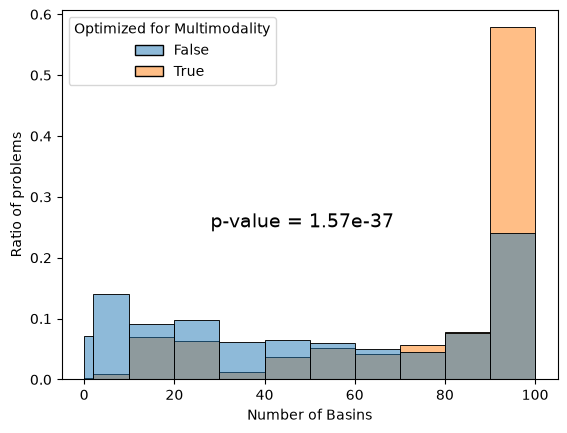

Fitness Analysis Multimodal
Mean: 0.9722492005451613
Over 0.9:0.3582474226804124
Over 0.99:0.3582474226804124
GlobalLocal problem ratio: 0.5709090909090909
Optima Contrast
MannwhitneyuResult(statistic=np.float64(38251.0), pvalue=np.float64(3.2172961168477354e-07))
Fitness Analysis Contrast
Mean: 0.8320496825428748
Over 0.9:0.09090909090909091
Over 0.99:0.09090909090909091


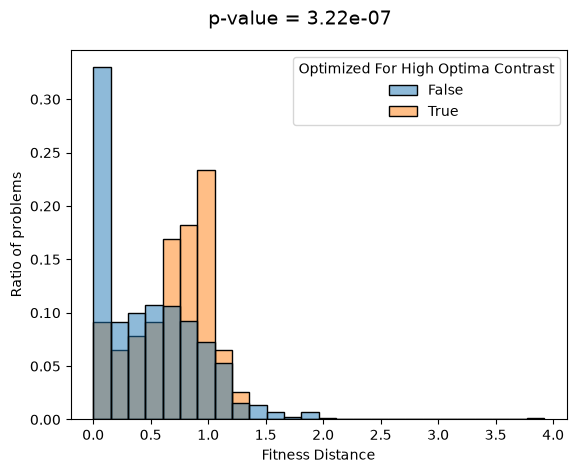

Basin Size problem ratio: 0.8945454545454545
Basin Size
MannwhitneyuResult(statistic=np.float64(49585.0), pvalue=np.float64(0.00011061031556947886))


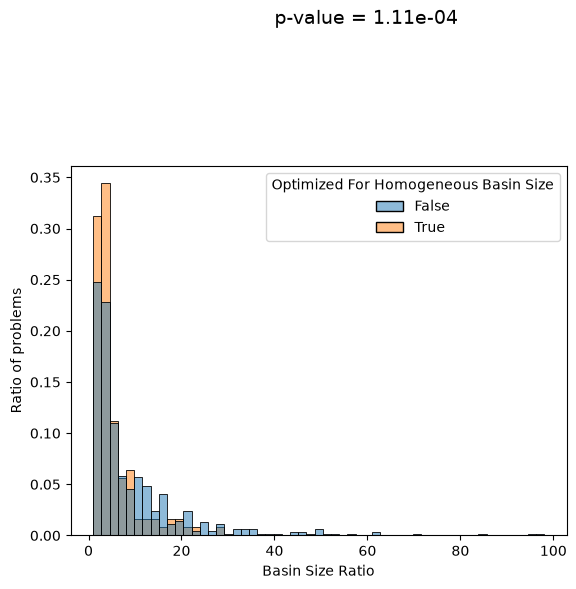

Fitness Analysis Basin Size
Mean: 0.95369664812088
Over 0.9:0.6350877192982456
Over 0.99:0.6350877192982456


In [1]:
"""
Parses the results of the basin of attraction analysis for the LLaMEA problems, and calculates statistics for the analyzed high level properties
"""

import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu




base_folder = "/local/bodasap/LLaMEA/basinsattribution-main/outputs_hybrid"



def find_best_homogeneous():
    data  = get_basin_data("Homogeneous", NOT=False)
    data = data[data.match]
    data = data.sort_values("fitness", ascending = False)
    return(data)

def get_basin_data(prop, folder = base_folder, NOT = False, paired=True):
    all_jsons_yes = []
    all_jsons_no = []
    all_jsons_exclude = []
    all_files = os.listdir(folder)
    all_files = [x for x in all_files if ".DS_Store" not in x]
    prop_files_not = []
    prop_files_exclude = []
    
    
    if not paired:        
        prop_files = [x for x in all_files if f"ELA-{prop}-sharing.jsonl" in x]
        
    
    else:
        prop_files = [x for x in all_files if prop in x]
    if NOT:
        prop_files_not = [x for x in prop_files if f"NOT" in x]
        
    prop_files = [x for x in prop_files if "NOT" not in x]
   
    
    for file in all_files:
        full_path = f"{folder}/{file}"
        jsonObj = pd.read_json(path_or_buf=full_path, lines=True)
        jsonObj["file"] = file
        if NOT:
            if file in prop_files:
                all_jsons_yes.append(jsonObj)
            if file in prop_files_not:
                all_jsons_no.append(jsonObj)
            else:
                all_jsons_exclude.append(jsonObj)
                
        if file in prop_files:
            all_jsons_yes.append(jsonObj)
        else:
            all_jsons_no.append(jsonObj)
            
    pd_yes = pd.concat(all_jsons_yes)
    pd_yes["match"] = True
    pd_no = pd.concat(all_jsons_no)
    pd_no["match"] = False
    
    if NOT:    
        pd_exclude = pd.concat(all_jsons_exclude)
        pd_exclude["match"] = None
        return (pd.concat([pd_yes, pd_no, pd_exclude]))
    else:
        return (pd.concat([pd_yes, pd_no]), len(prop_files))
   


def test_multimodality():
    data, num_files = get_basin_data("Multimodality", paired = True)
    to_keep = []
    for i in range(len(data)):
        if data.iloc[i]["match"] and data.iloc[i].metadata["score_Multimodality_2D"] < 0.5:
            to_keep.append(False)
        else:
            to_keep.append(True)
    max_problems = num_files * 55
    to_keep = np.array(to_keep)
    data_filtered = data[to_keep]
    
    data_filtered = data_filtered.reset_index()
    current_problems = len(data_filtered[data_filtered.match])
    print(f"Multimodal problem ratio: {current_problems/max_problems}")
    
    
    x_test = data_filtered[data_filtered.match].nr_of_basins
    y_test  = data_filtered[~data_filtered.match].nr_of_basins
    contrast_test = mannwhitneyu(x_test, y_test)
    print("Multimodality")
    print(contrast_test)
    
    data_filtered["Optimized for Multimodality"] = data_filtered.match
    data_filtered["Number of Basins"]  = data_filtered.nr_of_basins
    ax = sns.histplot(data = data_filtered, x="Number of Basins", hue="Optimized for Multimodality", stat = "probability", common_norm = False,
                      bins = [0,2,10,20,30,40,50,60,70,80,90,100])
    ax.set(ylabel='Ratio of problems')
    plt.text(28, 0.25, f"p-value = {contrast_test.pvalue:.2e}", fontsize=14)
    plt.show()
    
    selector = data_filtered["Optimized for Multimodality"]
    df1 = data_filtered[selector]
    selector2 = data_filtered[selector]["Number of Basins"] == 1
    df2 = df1[selector2]
    
    mean_false = data_filtered[~selector]["Number of Basins"].mean()
    means_success = data_filtered[selector]["Number of Basins"]
    over_1 =  (means_success > 1).sum() / len(means_success)
    over_15 = (means_success > mean_false * 1.5).sum() / len(means_success)
    over_20 = (means_success > mean_false * 2).sum() / len(means_success)
    over_30 = (means_success > mean_false * 3).sum() / len(means_success)
    
    
    data_match = data[data.match]
    mean_fitness= data_match.fitness.mean()
    over_09 = len(data_match[data_match.fitness>0.9])  / len(data_match)
    over_099 =  len(data_match[data_match.fitness>0.99]) / len(data_match)
    fitness_2D = []
    fitness_5D = []
    fitness_10D = []
    metadata_name  = "score_Multimodality"
    data_match = data_filtered[data_filtered.match]
    for i in range(len(data_match)):
        row = data_match.iloc[i].metadata
        fitness_2D.append(row[f"{metadata_name}_2D"])
        fitness_5D.append(row[f"{metadata_name}_5D"])
        fitness_10D.append(row[f"{metadata_name}_10D"])
    mean_fitness_2D= np.mean(fitness_2D)
    
    print("Fitness Analysis Multimodal")
    print(f"Mean: {mean_fitness_2D}")
    print(f"Over 0.9:{over_09}")
    print(f"Over 0.99:{over_09}")
    
    return(contrast_test, over_15, over_20, over_30)


def get_fitness_data_llm(_id, fitness_file = "/local/bodasap/LLaMEA/basinsattribution-main/llm_max_3107.csv"):
    fitness_data = pd.read_csv(fitness_file)
    fitness_data_problem = fitness_data[(fitness_data.id == _id)]
    if len(fitness_data_problem) == 0:
        return None
    fitness_data_problem = fitness_data[(fitness_data.id == _id)].iloc[0]
    return fitness_data_problem
    

    
def test_contrast():
    fitness_diffs = []
    data, num_files = get_basin_data("GlobalLocal", paired = True)
    to_keep = []
    for i in range(len(data)):
        if data.iloc[i]["match"] and data.iloc[i].metadata["score_GlobalLocal_2D"] < 0.5:
            to_keep.append(False)
        else:
            to_keep.append(True)
            
    
    to_keep = np.array(to_keep)
    data_filtered = data[to_keep]
    data_filtered = data_filtered.reset_index()
    
    max_problems = num_files * 55 
    current_problems = len(data_filtered[data_filtered.match])
    print(f"GlobalLocal problem ratio: {current_problems/max_problems}")
    skipped = [False] * len(data_filtered)
    for i in range(len(data_filtered)):
        
        data_row =  data_filtered.iloc[i]
        fitness_data = get_fitness_data_llm(data_row.id)
        if fitness_data is None:
            skipped[i] = True
            continue
        basins = data_row.basin_info

        basins = pd.DataFrame(basins, columns = ["num_runs", "loc", "fitness"])
        basins.fitness= basins.fitness - fitness_data["min_orig"]
        if (basins.fitness.min() < 0):
            basins.fitness = basins.fitness - basins.fitness.min()
        basins["fitness_means"] = basins.fitness * basins.num_runs
        mean_fitness = basins.fitness_means.sum() /  basins.num_runs.sum() #gives an average fitness of each run, rather than per basin
        max_fitness = basins.fitness.max()
        min_fitness = basins.fitness.min()
        
        mean_diff = basins.fitness.mean()-basins.fitness.min()
        mean_diff = mean_diff / np.abs(fitness_data["mean"])
        fitness_diffs.append(mean_diff)
    
    data_filtered["Skip"] = skipped
    data_filtered = data_filtered[~data_filtered.Skip]  
    data_filtered["Fitness Distance"] = fitness_diffs
    data_filtered["Optimized For High Optima Contrast"] = data_filtered.match
    
    x_test = data_filtered[data_filtered.match]["Fitness Distance"]
    x_test = x_test[~np.isnan(x_test)]
    y_test  = data_filtered[~data_filtered.match]["Fitness Distance"]
    y_test = y_test[~np.isnan(y_test)]
    contrast_test = mannwhitneyu(x_test, y_test)
    print("Optima Contrast")
    print(contrast_test)
    
    ax = sns.histplot(data = data_filtered, x="Fitness Distance", hue="Optimized For High Optima Contrast", stat = "probability", common_norm = False)
    ax.set(ylabel='Ratio of problems')
    plt.text(1, 0.37, f"p-value = {contrast_test.pvalue:.2e}", fontsize=14)
    
    
    
    
    selector = data_filtered["Optimized For High Optima Contrast"]
    
    mean_false = data_filtered[~selector]["Fitness Distance"].mean()
    means_success = data_filtered[selector]["Fitness Distance"]
    over_1 =  (means_success > 1).sum() / len(means_success)
    over_15 = (means_success > mean_false * 1.5).sum() / len(means_success)
    over_20 = (means_success > mean_false * 2).sum() / len(means_success)
    over_30 = (means_success > mean_false * 3).sum() / len(means_success)
    
    fitness_2D = []
    fitness_5D = []
    fitness_10D = []
    metadata_name  = "score_GlobalLocal"
    data_match = data_filtered[data_filtered.match]
    for i in range(len(data_match)):
        row = data_match.iloc[i].metadata
        fitness_2D.append(row[f"{metadata_name}_2D"])
        fitness_5D.append(row[f"{metadata_name}_5D"])
        fitness_10D.append(row[f"{metadata_name}_10D"])
    mean_fitness_2D= np.mean(fitness_2D)
    mean_fitness_5D= np.mean(fitness_5D)
    mean_fitness_10D= np.mean(fitness_10D)
    over_09 = len(data_match[data_match.fitness>0.9])  / len(data_match)
    over_099 =  len(data_match[data_match.fitness>0.99]) / len(data_match)
    print("Fitness Analysis Contrast")
    print(f"Mean: {mean_fitness_2D}")
    print(f"Over 0.9:{over_09}")
    print(f"Over 0.99:{over_09}")
    plt.show()
    return(contrast_test)
    
    


def test_basin_size_homogeneity():
    fitness_diffs = []
    data, num_files = get_basin_data("Basins", NOT = False,  paired = True)
    data = data[~data["match"].isnull()]
    data.match = data.match.astype(bool)
    to_keep = []
    for i in range(len(data)):
        if data.iloc[i]["match"] and data.iloc[i].metadata["score_Basins_2D"] < 0.5:
            to_keep.append(False)
        else:
            to_keep.append(True)
    to_keep = np.array(to_keep)
    data_filtered = data[to_keep]


    
    
    data_filtered = data_filtered.reset_index()
    max_problems = num_files * 55
    current_problems = len(data_filtered[data_filtered.match])
    print(f"Basin Size problem ratio: {current_problems/max_problems}")
    run_sd = []
    run_max = []
    data_match = data[data.match]
    mean_fitness= data_match.fitness.mean()
    over_09 = len(data_match[data_match.fitness>0.9])  / len(data_match)
    over_099 =  len(data_match[data_match.fitness>0.99]) / len(data_match)
    data_row_skipped = [False] * len(data_filtered)
    for i in range(len(data_filtered)):
        data_row = data_filtered.iloc[i]
        fitness_data = get_fitness_data_llm(data_row.id)
        if fitness_data is None:
            # print(f"Skipping {data_row.id} as no fitness data found")
            # update the data_row_skipped list to mark this row as skipped
            data_row_skipped[i] = True
            continue
        basins = data_row.basin_info
        basins = pd.DataFrame(basins, columns = ["num_runs", "loc", "fitness"])
        basins.fitness= basins.fitness - fitness_data["min_orig"]

        basin_len=len(basins)
        max_runs = basins.num_runs.max()
        min_runs = basins.num_runs.min()
        mean_runs = basins.num_runs.mean()
        max_runs_ratio = (max_runs/min_runs)
        sd_runs = basins.num_runs.std(ddof=0)
        run_sd.append(sd_runs)
        if len(basins) == 100:
            run_max.append(-1)
        else:
            run_max.append(max_runs_ratio)
        if data_row.match:
            pass
            #print("A")
        if max_runs_ratio < 2 and data_filtered.iloc[i].match:
            pass
            #print("AAA")
            #print(data_filtered.iloc[i])

    # update the data_filtered DataFrame to remove the skipped rows
    data_filtered = data_filtered[~np.array(data_row_skipped)]
        
    data_filtered["SD"] = run_sd
    data_filtered["Max"] = run_max
    data_filtered["Optimized For Homogeneous Basin Size"] = data_filtered.match
    
    data_filtered.reset_index()
    x_test = data_filtered[data_filtered.match]["SD"]
    y_test  = data_filtered[~data_filtered.match]["SD"]
    contrast_test_sd = mannwhitneyu(x_test, y_test)
    
    x_test = data_filtered[data_filtered.match]["Max"] 
    y_test  = data_filtered[~data_filtered.match]["Max"] 
    contrast_test_max = mannwhitneyu(x_test, y_test)
    print("Basin Size")
    print(contrast_test_max)
    
      
    data_filtered["Basin Size Ratio"] = data_filtered.Max  
    data_filtered = data_filtered[data_filtered["Max"] > 0]
    
    
    ax=sns.histplot(data = data_filtered, x="Basin Size Ratio", hue="Optimized For Homogeneous Basin Size", stat = "probability", common_norm = False)
    ax.set(ylabel='Ratio of problems')
    plt.text(40, 0.5, f"p-value = {contrast_test_max.pvalue:.2e}", fontsize=14)
    plt.show()
    

    
    
    selector = data_filtered["Optimized For Homogeneous Basin Size"]
    
    
    
    
    data_match = data[data.match]
    mean_fitness= data_match.fitness.mean()
    over_09 = len(data_match[data_match.fitness>0.9])  / len(data_match)
    over_099 =  len(data_match[data_match.fitness>0.99]) / len(data_match)
    
    mean_false = data_filtered[~selector]["Max"].mean()
    means_success = data_filtered[selector]["Max"]
    over_1 =  (means_success > 1).sum() / len(means_success)
    over_15 = (mean_false > means_success * 1.5).sum() / len(means_success)
    over_20 = (mean_false > means_success * 2).sum() / len(means_success)
    over_30 = (mean_false > means_success * 3).sum() / len(means_success)
    
    fitness_2D = []
    fitness_5D = []
    fitness_10D = []
    metadata_name  = "score_Basins"
    data_match = data_filtered[data_filtered.match]
    for i in range(len(data_match)):
        row = data_match.iloc[i].metadata
        fitness_2D.append(row[f"{metadata_name}_2D"])
        fitness_5D.append(row[f"{metadata_name}_5D"])
        fitness_10D.append(row[f"{metadata_name}_10D"])
    mean_fitness_2D= np.mean(fitness_2D)
    print("Fitness Analysis Basin Size")
    print(f"Mean: {mean_fitness_2D}")
    print(f"Over 0.9:{over_09}")
    print(f"Over 0.99:{over_09}")
    
    return(contrast_test_sd, contrast_test_max)
multimodal_test = test_multimodality()
contrast_result = test_contrast()
hom_result_sd , hom_result_max = test_basin_size_homogeneity()

